# Reverberation Preprocessing + 6-View Fusion Workflow

This notebook demonstrates how to use the refactored reverberation preprocessing utilities in `src/preprocessing.py` with **Napari-first visualization**.

Workflow:
1. Process one DICOM view (parameter estimation + filtering).
2. Process 6 views and save filtered volumes.
3. Register/fuse the filtered 6-view set with the same `VolumeRegistrator` pipeline used in `volume_reconstruction_registration_exploration.ipynb`.


In [1]:
from pathlib import Path
import sys

import numpy as np
import SimpleITK as sitk
import napari
from napari.utils import nbscreenshot

# Make project modules importable from this notebook location
PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from preprocessing import (
    load_dicom_volume,
    estimate_reverberation_parameters,
    apply_reverberation_filters,
)
from volumeRegistrator import VolumeRegistrator

print(f'Project root: {PROJECT_ROOT}')
print(f'Source dir:   {SRC_DIR}')


Project root: C:\Users\corba\Documents\eco-root
Source dir:   C:\Users\corba\Documents\eco-root\src


## 1) Configure paths


In [2]:
dicom_input_dir = PROJECT_ROOT / 'data' / 'ultrasound' / 'raices reales' / '1'
filtered_volumes_dir = PROJECT_ROOT / 'data' / 'volumes' / 'reverb_filtered'
results_dir = PROJECT_ROOT / 'data' / 'results'

filtered_volumes_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

# ROI from reverberation report (inclusive): (min_x, max_x, min_y, max_y)
ROI_XYXY = (401, 619, 116, 689)

# Spatial spacing aligned with reconstruction exploration notebook
VOXEL_SPACING = (0.187, 0.188, 3.95)  # (x, y, z) in mm

dicom_files = sorted(dicom_input_dir.glob('*.dcm'))
print(f'Found {len(dicom_files)} DICOM files in {dicom_input_dir}')
if len(dicom_files) == 0:
    raise FileNotFoundError(f'No DICOM files found in {dicom_input_dir}')



Found 6 DICOM files in C:\Users\corba\Documents\eco-root\data\ultrasound\raices reales\1


## 2) Process one DICOM view

Estimate reverberation parameters and apply filters for one selected view.


In [3]:
selected_index = 0
selected_dicom_path = dicom_files[selected_index]

volume_raw, ds = load_dicom_volume(selected_dicom_path, roi_xyxy=ROI_XYXY)
params, diagnostics = estimate_reverberation_parameters(volume_raw)

volume_filtered = apply_reverberation_filters(
    volume_raw,
    params,
)

print(f'Selected DICOM: {selected_dicom_path.name}')
print(f'Raw cropped volume shape: {volume_raw.shape}')
print(f'CineRate: {ds.get("CineRate", "N/A")}')
print('--- Estimated reverberation parameters ---')
print(f'Peak frequency (median): {params.peak_frequency_cycles_per_pixel:.5f} cycles/pixel')
print(f'Spacing median: {params.spacing_median_px:.3f} px')
print(f'Estimated period: {params.estimated_period_px} px')
print(f'Comb harmonics: {params.comb_harmonics}')


Selected DICOM: 001.dcm
Raw cropped volume shape: (189, 574, 219)
CineRate: 19
--- Estimated reverberation parameters ---
Peak frequency (median): 0.09408 cycles/pixel
Spacing median: 10.630 px
Estimated period: 10 px
Comb harmonics: (1, 2, 3, 4, 5)


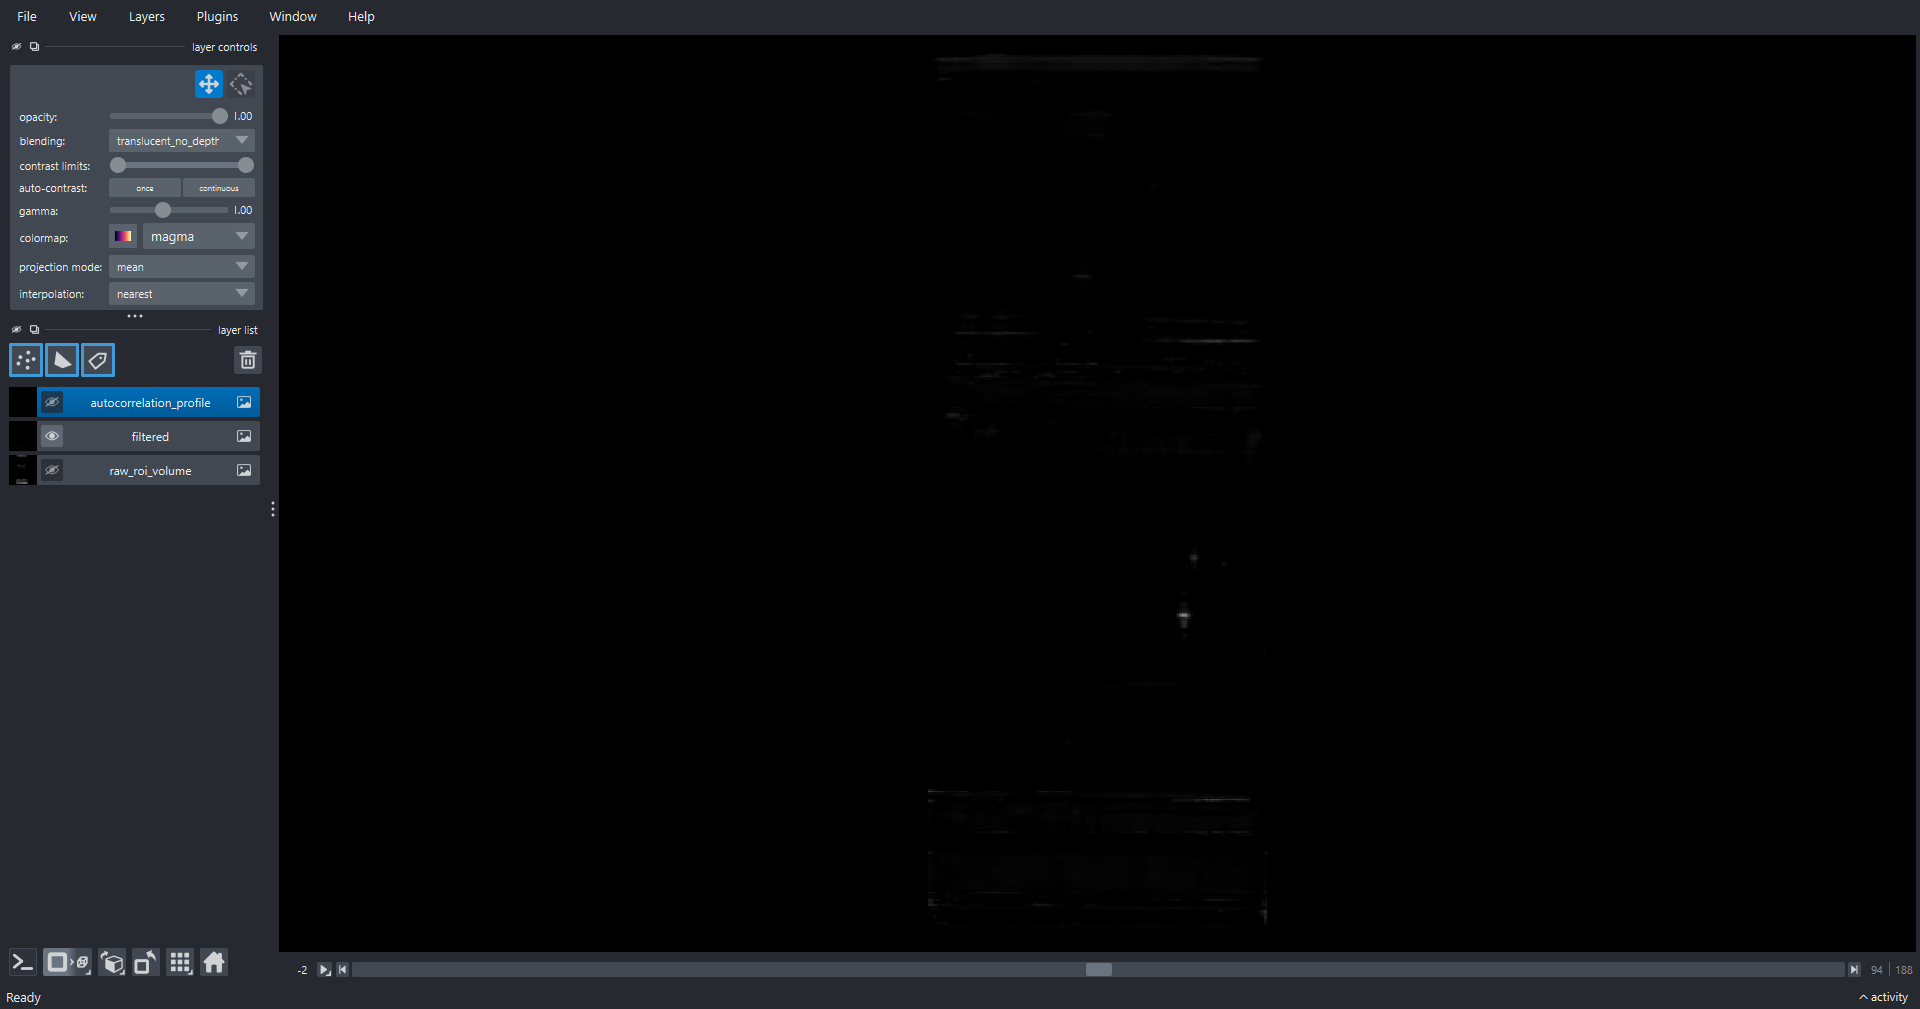

In [4]:
# Napari comparison for one view
viewer_one = napari.Viewer(title='Single-view reverberation preprocessing QC')
viewer_one.add_image(volume_raw, name='raw_roi_volume', colormap='gray').visible = False
viewer_one.add_image(volume_filtered,
                     name='filtered',
                     colormap='gray',
                     visible=True ,
                     contrast_limits=(0, volume_filtered.max())
                     )

# Optional diagnostics layer
viewer_one.add_image(
    diagnostics.autocorrelation[np.newaxis, :, np.newaxis].astype(np.float32),
    name='autocorrelation_profile',
    colormap='magma',
    visible=False,
)

nbscreenshot(viewer_one)


## 3) Process all 6 views and save filtered `.nii.gz` volumes


In [5]:
def preprocess_dicom_to_sitk_volume(dicom_path, roi_xyxy, voxel_spacing):
    """Load one DICOM view, estimate/apply reverberation filters, keep all planes, return SITK volume + metadata."""
    vol_raw, ds_local = load_dicom_volume(dicom_path, roi_xyxy=roi_xyxy)
    params_local, _ = estimate_reverberation_parameters(vol_raw)
    vol_filtered = apply_reverberation_filters(
        vol_raw,
        params_local,
        clip_nonnegative=True,
    )

    fps = float(ds_local.get('CineRate', 30.0))
    step = 1
    sampled = vol_filtered.astype(np.float32)

    sitk_volume = sitk.GetImageFromArray(sampled)
    sitk_volume.SetSpacing(voxel_spacing)

    meta = {
        'cine_rate': fps,
        'sampling_step': step,
        'raw_shape': tuple(vol_raw.shape),
        'sampled_shape': tuple(sampled.shape),
        'estimated_period_px': params_local.estimated_period_px,
        'peak_frequency': params_local.peak_frequency_cycles_per_pixel,
    }
    return sitk_volume, sampled, meta

if len(dicom_files) < 6:
    raise ValueError(f'Expected at least 6 views, found {len(dicom_files)}.')

selected_views = dicom_files[:6]
saved_filtered_volumes = []
preview_arrays = []

for dcm_path in selected_views:
    vol_img, sampled_arr, meta = preprocess_dicom_to_sitk_volume(
        dcm_path,
        roi_xyxy=ROI_XYXY,
        voxel_spacing=VOXEL_SPACING,
    )

    out_path = filtered_volumes_dir / f'volume_reverb_filtered_{dcm_path.stem}.nii.gz'
    sitk.WriteImage(vol_img, str(out_path))
    saved_filtered_volumes.append(out_path)
    preview_arrays.append(sampled_arr)

    print(
        f'Saved {out_path.name} | raw={meta["raw_shape"]} -> sampled={meta["sampled_shape"]} '
        f'| fps={meta["cine_rate"]:.1f} | step={meta["sampling_step"]} '
        f'| period~{meta["estimated_period_px"]} px'
    )

print(f'Created {len(saved_filtered_volumes)} filtered volumes in {filtered_volumes_dir}')





Saved volume_reverb_filtered_001.nii.gz | raw=(189, 574, 219) -> sampled=(189, 574, 219) | fps=19.0 | step=1 | period~10 px
Saved volume_reverb_filtered_002.nii.gz | raw=(189, 574, 219) -> sampled=(189, 574, 219) | fps=19.0 | step=1 | period~11 px
Saved volume_reverb_filtered_003.nii.gz | raw=(188, 574, 219) -> sampled=(188, 574, 219) | fps=19.0 | step=1 | period~11 px
Saved volume_reverb_filtered_004.nii.gz | raw=(189, 574, 219) -> sampled=(189, 574, 219) | fps=19.0 | step=1 | period~10 px
Saved volume_reverb_filtered_005.nii.gz | raw=(190, 574, 219) -> sampled=(190, 574, 219) | fps=19.0 | step=1 | period~13 px
Saved volume_reverb_filtered_006.nii.gz | raw=(189, 574, 219) -> sampled=(189, 574, 219) | fps=19.0 | step=1 | period~9 px
Created 6 filtered volumes in C:\Users\corba\Documents\eco-root\data\volumes\reverb_filtered


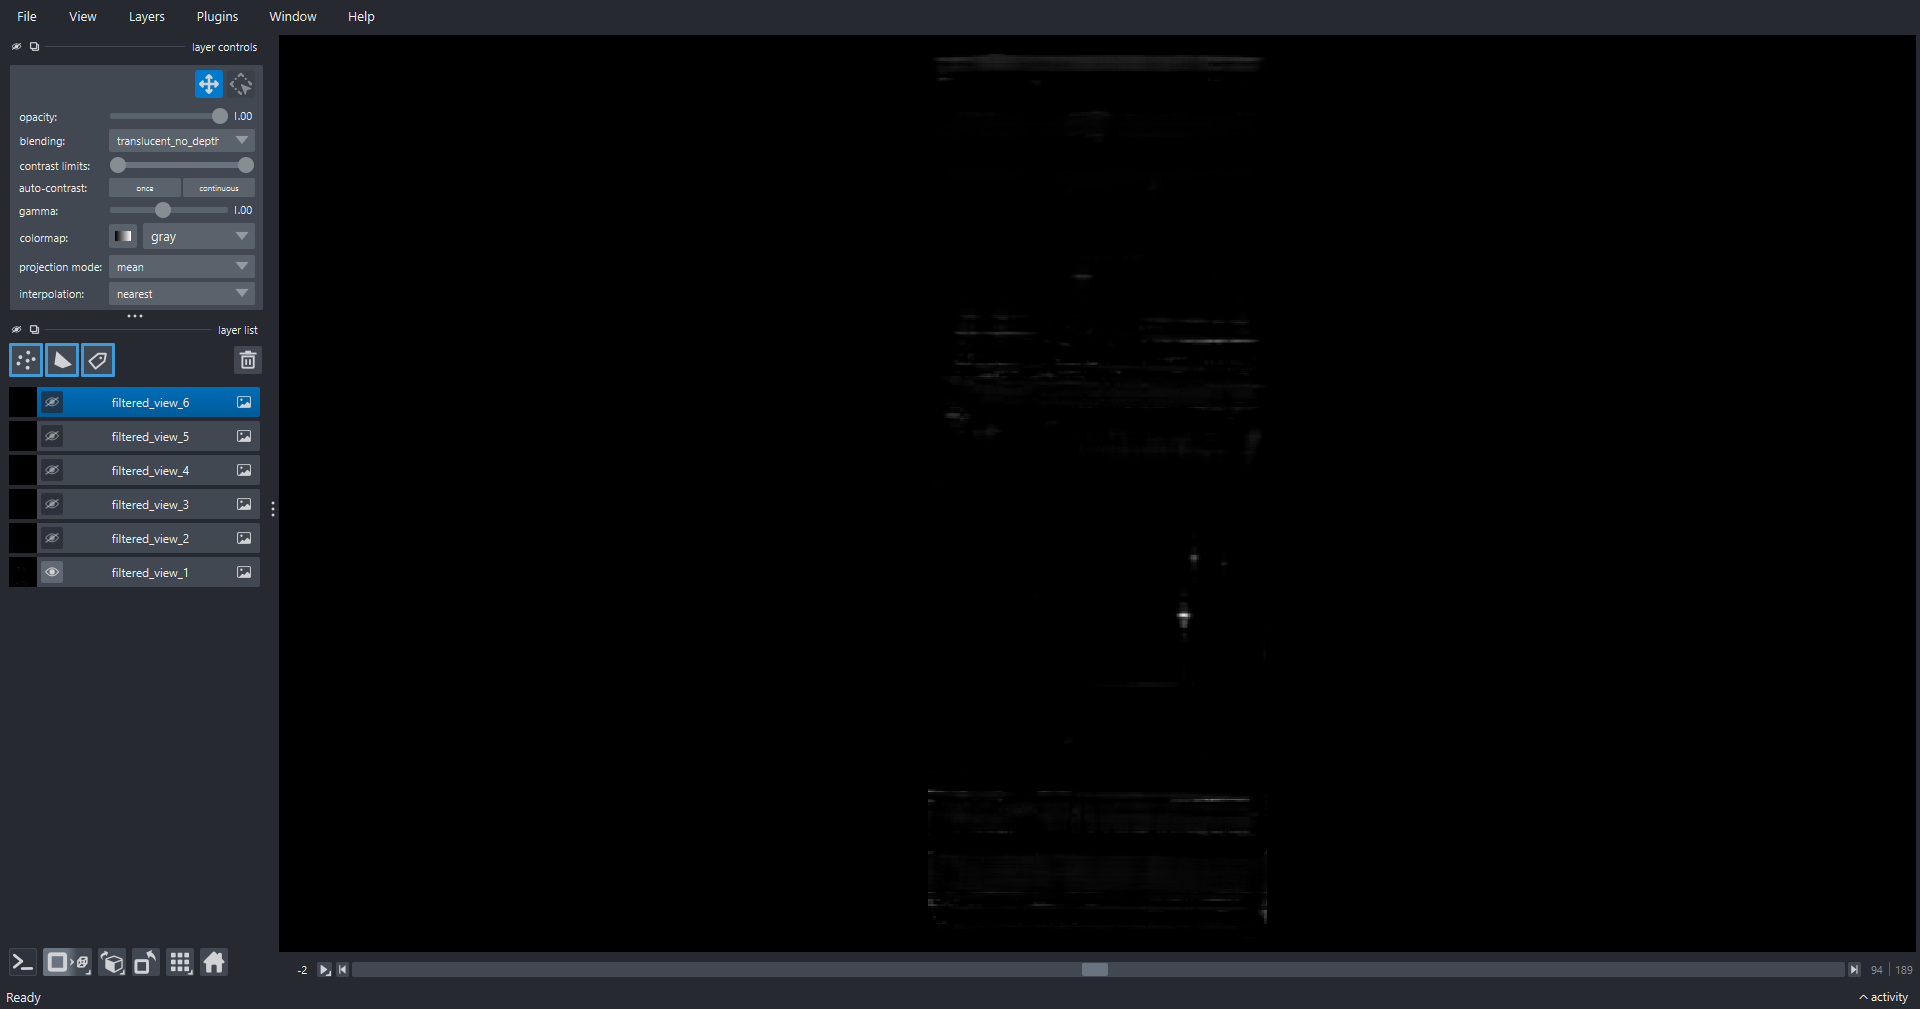

In [6]:
# Napari multi-view QC: add all six filtered views as separate layers
viewer_multi = napari.Viewer(title='Filtered 6-view QC')
for idx, arr in enumerate(preview_arrays):
    viewer_multi.add_image(arr, name=f'filtered_view_{idx+1}',
                           colormap='gray',
                           visible=(idx == 0),
                           #scale=VOXEL_SPACING[::-1],
                           )

nbscreenshot(viewer_multi)



## 4) Register and fuse filtered volumes (same pipeline)


In [7]:
registrator = VolumeRegistrator(str(filtered_volumes_dir), output_dir=str(results_dir))
fused_path = registrator.process_volumes(output_filename='final_volume_reverb_filtered_mean_pipeline.nii.gz')
print('Fused output:', fused_path)

Successfully loaded 6 volumes from C:\Users\corba\Documents\eco-root\data\volumes\reverb_filtered
Processing volume 0 (volume_reverb_filtered_001)...
Processing volume 1 (volume_reverb_filtered_002)...
Processing volume 2 (volume_reverb_filtered_003)...
Processing volume 3 (volume_reverb_filtered_004)...
Processing volume 4 (volume_reverb_filtered_005)...
Processing volume 5 (volume_reverb_filtered_006)...
Fused hexagonal volume saved to: C:\Users\corba\Documents\eco-root\data\results\final_volume_reverb_filtered_mean_pipeline.nii.gz
Fused output: C:\Users\corba\Documents\eco-root\data\results\final_volume_reverb_filtered_mean_pipeline.nii.gz


Fused shape: (189, 676, 679)
Fused spacing: (3.950000047683716, 0.18799999356269836, 0.18700000643730164)


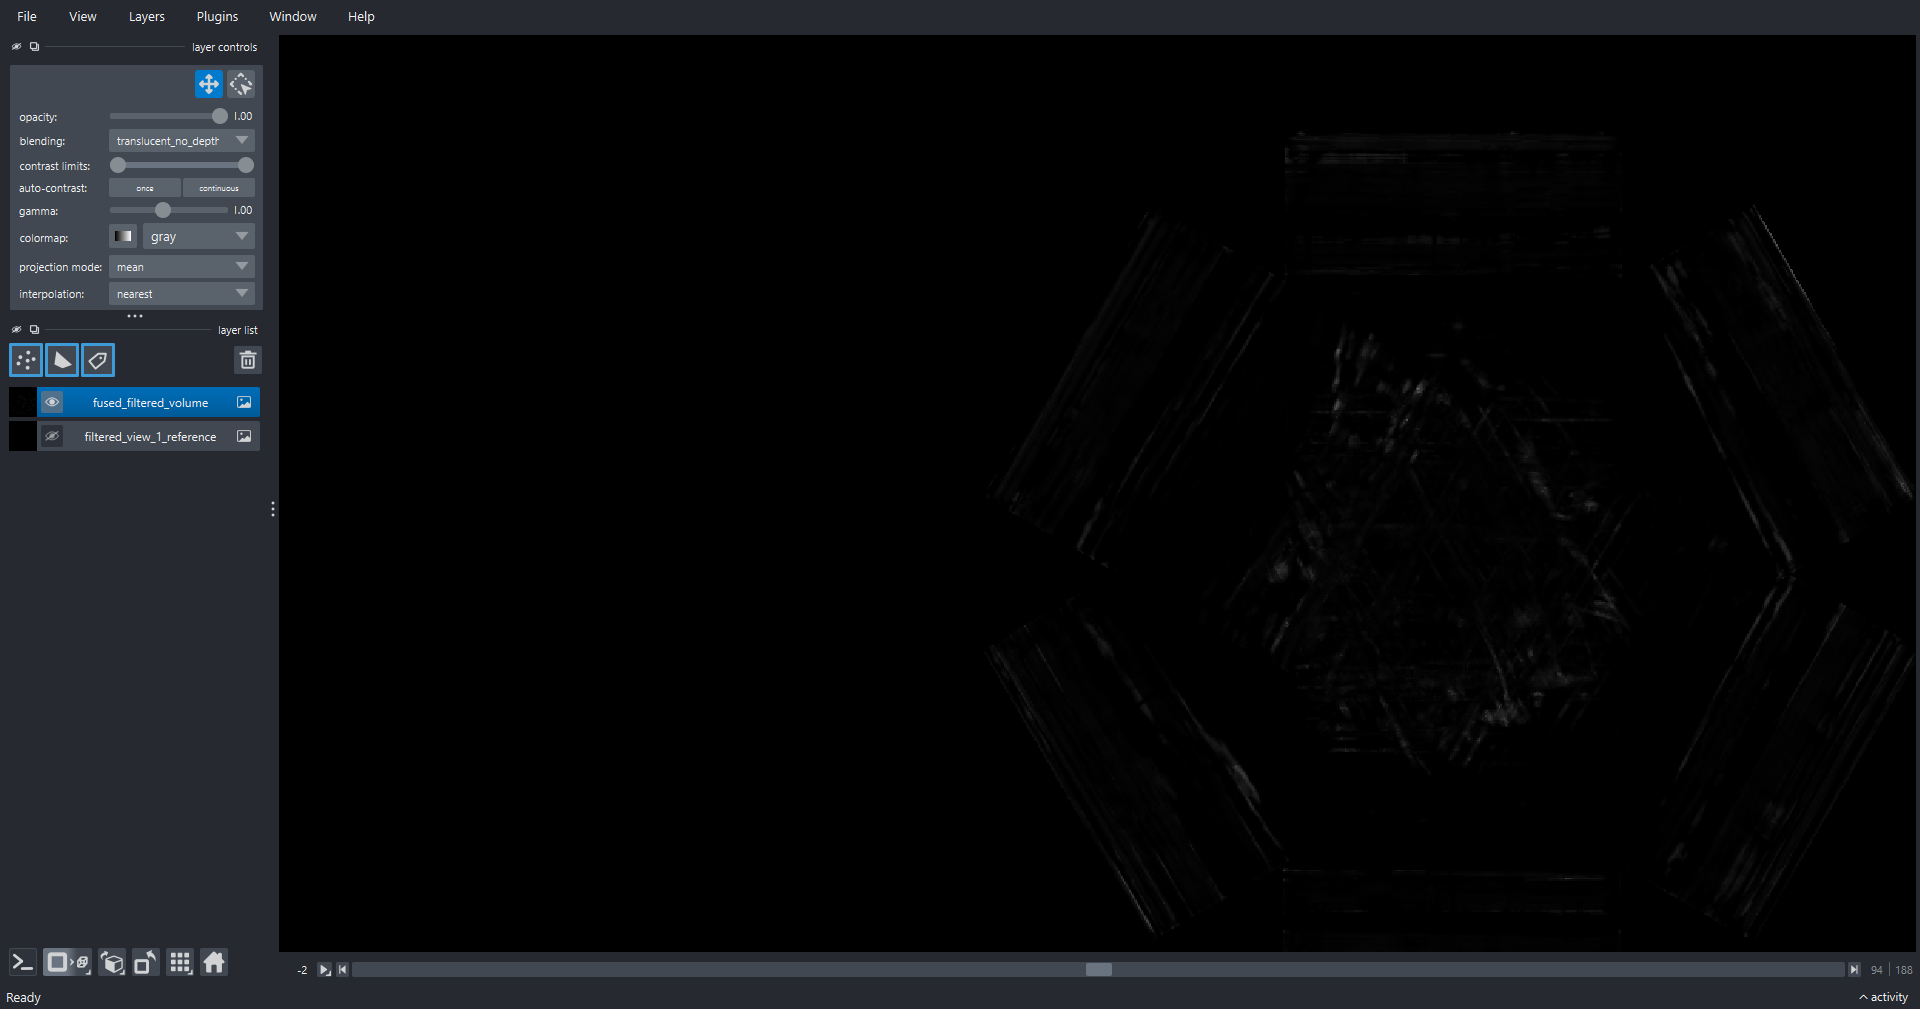

In [ ]:
# Napari final comparison: first filtered view vs fused output
fused_img = sitk.ReadImage(str(fused_path))
fused_arr = sitk.GetArrayFromImage(fused_img).astype(np.float32)
spacing = fused_img.GetSpacing()[::-1]

first_view_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(saved_filtered_volumes[0]))).astype(np.float32)

viewer_fused = napari.Viewer(title='Final fusion QC')
viewer_fused.add_image(first_view_arr, name='filtered_view_1_reference', colormap='gray', visible=False)
viewer_fused.add_image(fused_arr, name='fused_filtered_volume', colormap='gray')

print('Fused shape:', fused_arr.shape)
print('Fused spacing:', spacing)
nbscreenshot(viewer_fused)

